In [1]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import glob
import time
import scipy
import scipy.sparse as sp
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import issparse
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from itertools import chain
import re
import pickle as pkl
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix as mtrx
import utils as ut
#import plotting as plt2
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central


source_path = os.path.abspath("../distribution/")
sys.path.append(source_path)
import rebin as rb
import plots as plot
import old_plots as old_plot

/home/jduhamel/.conda/envs/pore_c/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/jduhamel/.conda/envs/pore_c/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/jduhamel/.conda/envs/pore_c/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


### Pull in Core

In [2]:
# Read in core incidence
path_clean = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_100000_core_current_1.h5ad"

start_time = time.time()  # Record the start time
cdata = sc.read_h5ad(path_clean)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

Time taken to read the file: 2.51 seconds
Memory usage: current 0.37 GB, difference +0.37 GB


### Pull in Desired Cell

In [34]:
# # Replace the specifc cell with a pickle object

# sc_path = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/singlecell_mESC_1000000_features_en.h5ad"

# bdata_main = sc.read_h5ad(sc_path)
# end_time = time.time()  # Record the end time
# print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
# sc.logging.print_memory_usage()

# bdata_main.obsm

In [35]:
#bdata = bdata_main.copy()

In [36]:
# cell_list = ['o3b27', 'o3b82', 'o3b79', 'o3b50', 'o3b09', 'o3b56', 'o3b80','o3b07']

# # extract the single-cell
# for cell_id in cell_list:
#     sc_data = bdata[:, bdata.var['basename'] == cell_id].copy()
#     H_cell_raw= sc_data.to_df()
#     H_cell = H_cell_raw.T.drop_duplicates().T  # Transpose, drop duplicates, transpose back
#     H_cell.columns = [f"{cell_id}_{x}" for x in H_cell.columns]
#     H_cell.to_pickle(f'/home/jduhamel/sc_pore_c/notebooks/distribution/H_cell_{cell_id}.pkl')
#     H_cell_raw.to_pickle(f'/home/jduhamel/sc_pore_c/notebooks/distribution/H_cell_raw_{cell_id}.pkl')
    

In [116]:
H_cell_file = open("/home/jduhamel/sc_pore_c/notebooks/distribution/cells/H_cell_o3b82.pkl", "rb")
H_cell = pkl.load(H_cell_file)

### RE-BINNING (1Mb -> 25Mb)

In [149]:
locus_set_counts_cell = rb.rebin_large(H_cell,dedup=True,invert=True,removal=True)

In [150]:
selected_hyperedges_cell = rb.select_top_hyperedges(locus_set_counts_cell, top_n=5)
im_cell = rb.build_selected_incidence_df(selected_hyperedges_cell, locus_set_counts_cell)

In [6]:
# with open('cell_o3b82/o3b82.pkl', 'wb') as file:
#     pkl.dump(im_cell, file)

### Combined Incidence/Histogram Plot

In [7]:
# ax = plot.genomic_combined_plot(
#     im_cell,
#     spath="hist_incidence_cell_o3b07",
#     shade_rows=True,
#     connect_nodes=True,
#     dpi=150,
#     node_labels=True,
#     figsize=(27, 9),
#     row_spacing=0.6,
#     col_spacing=0.7,
# )
# plt.show()

### Contact Matrices

In [45]:
# cell_list = ['o3b27', 'o3b82', 'o3b79', 'o3b50', 'o3b09', 'o3b56', 'o3b80','o3b07']

# incidence_list = []

# for cell_id in cell_list:
#     H_cell_file = open(f"/home/jduhamel/sc_pore_c/notebooks/distribution/cells/H_cell_{cell_id}.pkl", "rb")
#     H_cell = pkl.load(H_cell_file)
#     locus_set_counts_cell = rb.rebin_large(H_cell,dedup=True,invert=True,removal=True)
#     selected_hyperedges_cell = rb.select_top_hyperedges(locus_set_counts_cell, top_n=5)
#     im_cell = rb.build_selected_incidence_df(selected_hyperedges_cell, locus_set_counts_cell)
#     incidence_list.append(im_cell)

In [8]:
# incidence_list_copy = incidence_list
# with open('eight_cell_im.pkl', 'wb') as f:
#     pkl.dump(incidence_list, f)
incidence_list = []

with open('cells/eight_cell_im.pkl', 'rb') as file:
    incidence_list =  pkl.load(file)

incidence_list_2 =[]

with open('cells/eight_cell_core_im.pkl', 'rb') as file:
    incidence_list_2 =  pkl.load(file)



In [9]:
# Define this BEFORE plot_contact_matrices_panel
def normalize_contact_matrix(C, method='coverage'):
    if method == 'coverage':
        row_sums = C.sum(axis=1).astype(float)
        row_sums[row_sums == 0] = 1
        norm_factor = np.sqrt(np.outer(row_sums, row_sums))
        return C / norm_factor

    elif method == 'oe':
        row_sums = C.sum(axis=1).astype(float)
        total    = row_sums.sum()
        expected = np.outer(row_sums, row_sums) / total
        expected[expected == 0] = 1
        return C / expected

    elif method == 'zscore':
        mean = C.mean()
        std  = C.std()
        if std == 0:
            return np.zeros_like(C)
        return (C - mean) / std

    elif method == 'percentile':
        lo, hi = np.percentile(C, 1), np.percentile(C, 99)
        C_clipped = np.clip(C, lo, hi)
        if hi - lo == 0:
            return np.zeros_like(C)
        return (C_clipped - lo) / (hi - lo)

    else:
        raise ValueError(f"Unknown normalization method: '{method}'")

In [10]:
def plot_contact_matrices_panel(
    incidence_dfs,
    incidence_dfs_augmented,
    spath,
    log_transform=True,
    normalize=True,          # <-- NEW
    norm_method='coverage',  # <-- NEW
    cmap='Blues',
    dpi=200,
    figsize=(40, 12),
):
    assert len(incidence_dfs) == 8, "Exactly 8 incidence matrices are required."
    assert len(incidence_dfs_augmented) == 8, "Exactly 8 augmented incidence matrices are required."

    plt.rcParams['figure.dpi'] = dpi
    plt.rcParams["axes.edgecolor"] = "black"
    plt.rcParams["axes.linewidth"] = 2.50

    ##### Pre-compute contact matrices & global min/max #####
    def compute_plot_data(dfs):
        plot_data_list = []
        for df in dfs:
            H = df.values.astype(float)
            C = H @ H.T

            if normalize:                                              # <-- NEW
                C = normalize_contact_matrix(C, method=norm_method)   # <-- NEW

            plot_data_list.append(np.log1p(C) if log_transform else C)
        return plot_data_list

    plot_data_original  = compute_plot_data(incidence_dfs)
    plot_data_augmented = compute_plot_data(incidence_dfs_augmented)

    all_plot_data = plot_data_original + plot_data_augmented
    global_min = min(p.min() for p in all_plot_data)
    global_max = max(p.max() for p in all_plot_data)

    # <-- NEW: dynamic label based on what's active
    if normalize and log_transform:
        cbar_label = f'log(1 + Normalized Contacts) [{norm_method}]'
    elif normalize:
        cbar_label = f'Normalized Contacts [{norm_method}]'
    elif log_transform:
        cbar_label = 'log(1 + Shared Reads)'
    else:
        cbar_label = 'Shared Reads'

    axis_label = 'Chr 1 - 19, X'

    ##### Build figure: 2 rows x 8 cols #####
    fig, axes = plt.subplots(2, 8, figsize=figsize)

    row_labels    = ['', '']
    all_plot_rows = [plot_data_original, plot_data_augmented]

    for row_idx, (row_data, row_label) in enumerate(zip(all_plot_rows, row_labels)):
        for col_idx, (ax, plot_data) in enumerate(zip(axes[row_idx], row_data)):

            sns.heatmap(
                plot_data,
                ax=ax,
                cmap=cmap,
                square=True,
                vmin=global_min,
                vmax=global_max,
                cbar=False,
                linewidths=0.3,
                linecolor='white',
                xticklabels=False,
                yticklabels=False,
            )

            if row_idx == 0:
                ax.set_title(f'Cell {col_idx + 1}', fontsize=10, fontweight='bold', pad=6)

            if col_idx == 0:
                ax.set_xlabel(axis_label, fontsize=12, fontweight='bold')
                ax.set_ylabel(axis_label, fontsize=12, fontweight='bold')
            else:
                ax.set_xlabel('')
                ax.set_ylabel('')

            if col_idx == 0:
                ax.annotate(
                    row_label,
                    xy=(-0.35, 0.5),
                    xycoords='axes fraction',
                    fontsize=12,
                    fontweight='bold',
                    va='center',
                    ha='right',
                    rotation=90,
                )

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color('black')
                spine.set_linewidth(2.0)

    ##### Shared colorbar #####
    plt.subplots_adjust(wspace=0.02, hspace=0.15, bottom=0.12)

    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cax = fig.add_axes([0.78, 0.04, 0.12, 0.02])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label(cbar_label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    plt.savefig(spath, dpi=dpi, bbox_inches='tight')
    plt.show()

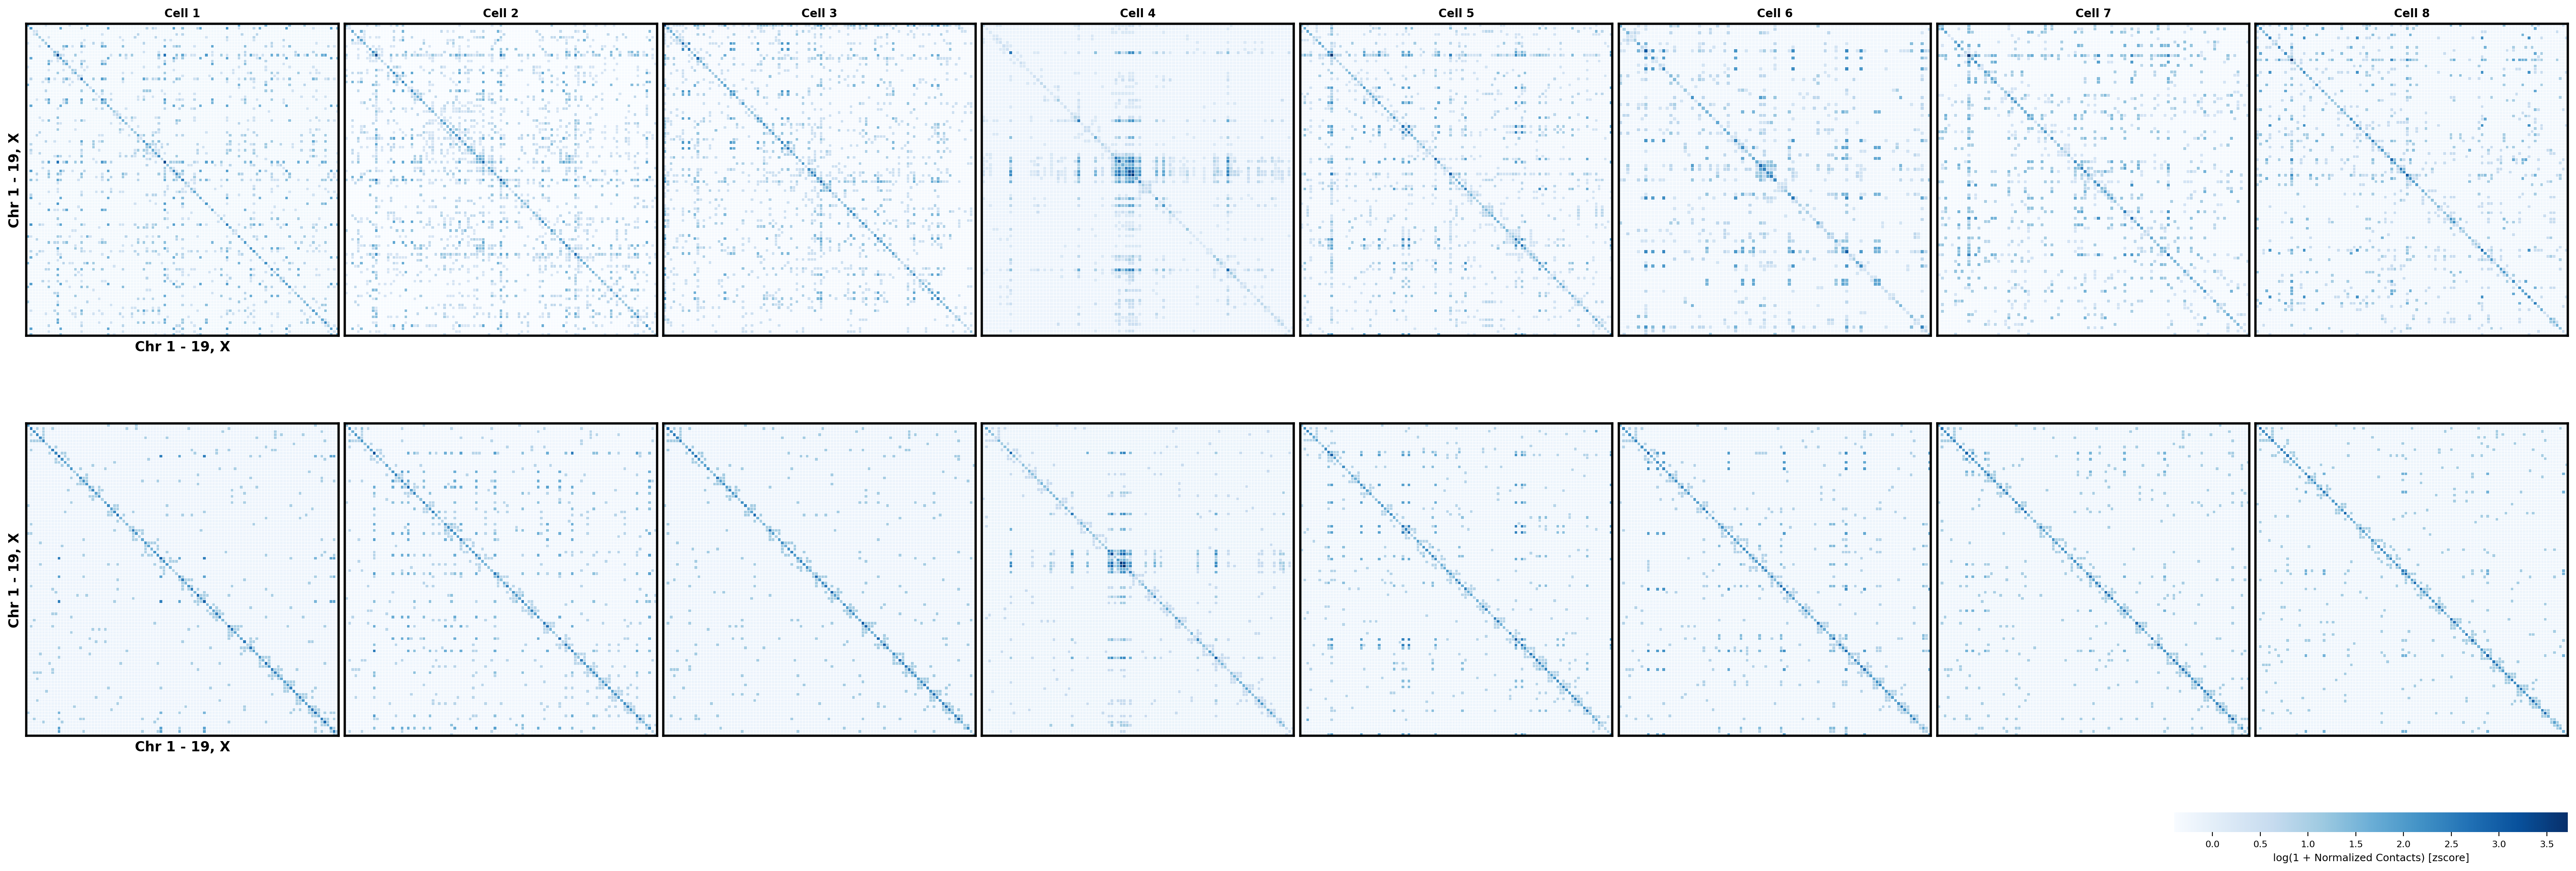

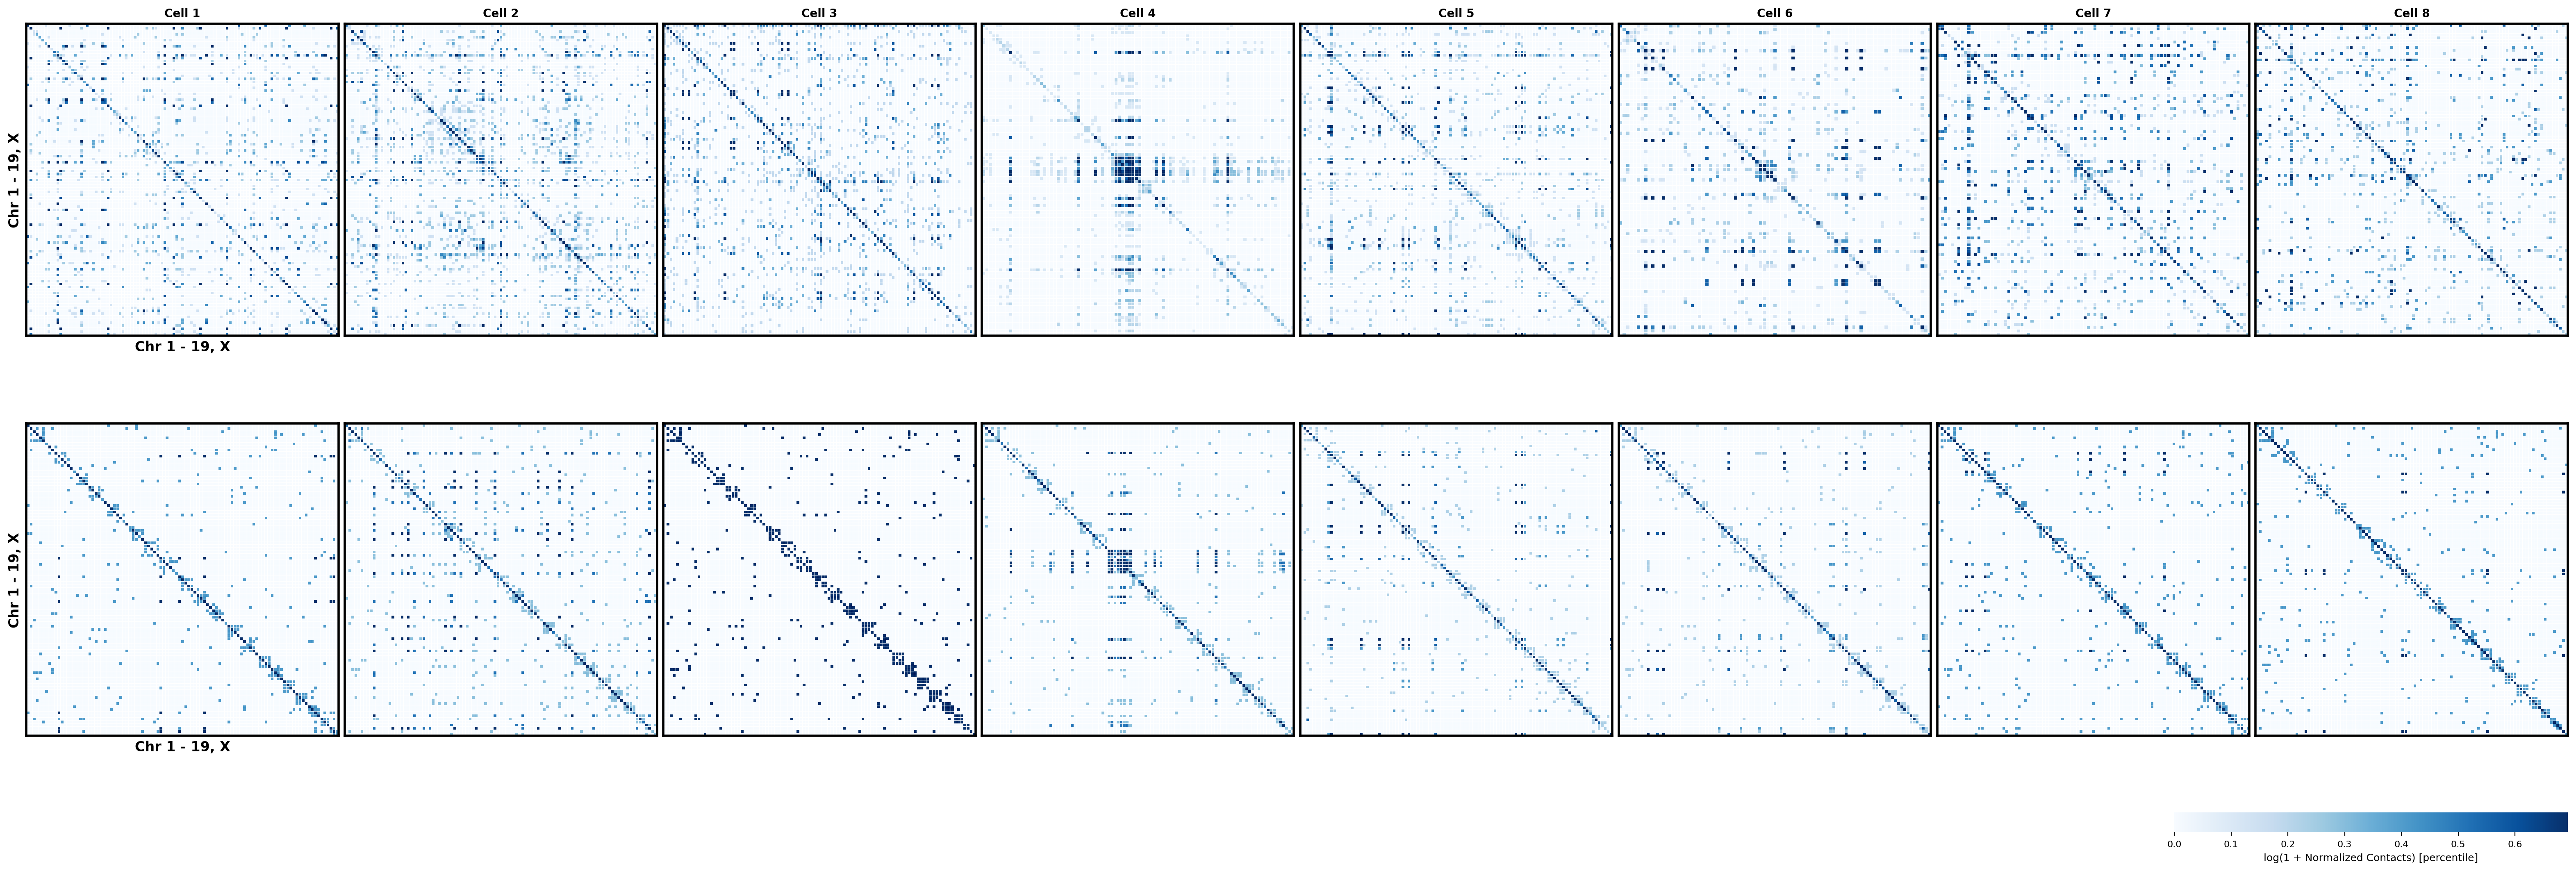

In [11]:
# # Default — coverage normalization active
# plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_normalize_coverage.png')

# # Every Method with Normalization on:
# plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_normalize_obs_exp.png', norm_method='oe')

plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_normalize_zscore.png', norm_method='zscore')

plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_normalize_percentile.png', norm_method='percentile')


# # Every Method with Normalization off:
# plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_coverage.png', normalize=False)

# plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_obs_exp.png', normalize=False, norm_method='oe')

# plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_zscore.png', normalize=False, norm_method='zscore')

# plot_contact_matrices_panel(incidence_list, incidence_list_2, 'cm_percentile.png', normalize=False, norm_method='percentile')

### Core Analysis

In [119]:
core_cell = cdata.X.todense()
core_cell_obs = cdata.obs
core_cell_var =cdata.var

In [120]:
bin_name = core_cell_obs.index
read_name = core_cell_var.index

core_df = pd.DataFrame(data=core_cell, index=bin_name, columns=read_name)

In [153]:
locus_set_counts_core = rb.rebin_large(core_df ,dedup=True,invert=True,removal=True)

In [154]:
selected_hyperedges_core= rb.select_top_hyperedges(locus_set_counts_core, top_n=10)

im_core = rb.build_selected_incidence_df(selected_hyperedges_core, locus_set_counts_core)

In [7]:
with open('core/core_IM.pkl', 'wb') as file:
    pkl.dump(im_core, file)

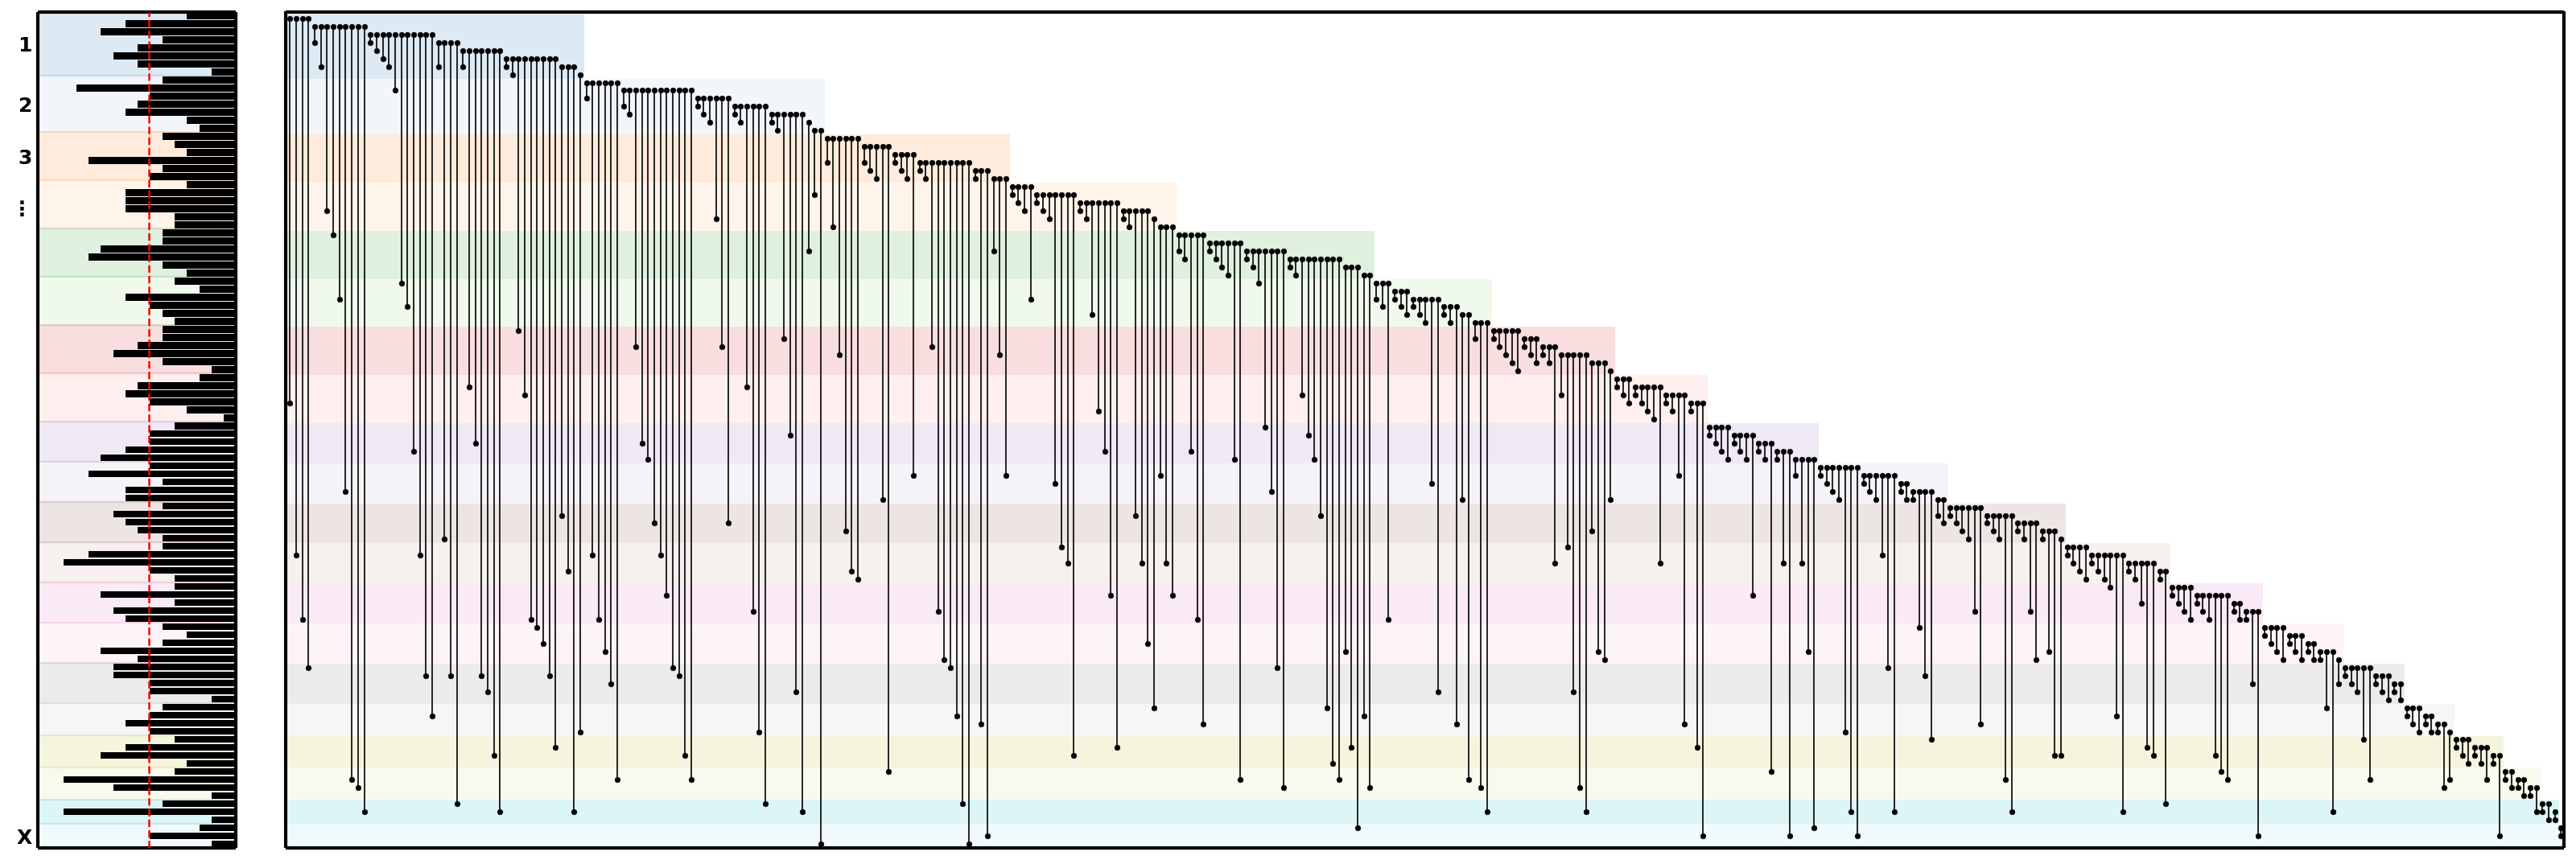

In [55]:
ax = plot.genomic_combined_plot(
    im_core,
    spath="hist_incidence_core",
    shade_rows=True,
    connect_nodes=True,
    dpi=150,
    node_labels=True,
    figsize=(27, 9),
    row_spacing=0.6,
    col_spacing=0.7,
)
plt.show()

# Overlay of Core onto SC

In [12]:
with open('cell_o3b82/cell_o3b82_IM.pkl', 'rb') as file:
    im_cell =  pkl.load(file)

with open('core/core_IM.pkl', 'rb') as file:
    im_core = pkl.load(file)

In [43]:
sort_cell= {col: im_cell.index[im_cell[col] != 0].tolist() for col in im_cell.columns}
sort_core = {col: im_core.index[im_core[col] != 0].tolist() for col in im_core.columns}

shared = {}
count=0
for key, value in sort_cell.items():
    count +=1 
    for key1, value1 in sort_core.items():
        if value == value1:
            shared[count] = value
        else:
            continue

In [55]:
def combine_locus_set_counts(counts_a: dict, counts_b: dict) -> dict:
    """
    Combine two locus_set_counts dicts (frozenset -> int) by summing
    counts for shared hyperedges and preserving unique ones from either.

    Parameters
    ----------
    counts_a : dict  Output of rebin_large() for matrix A
    counts_b : dict  Output of rebin_large() for matrix B

    Returns
    -------
    dict  Combined locus_set_counts sorted by frequency descending
    """
    combined = Counter(counts_a)   # start with a copy of A
    combined.update(counts_b)      # adds counts for shared keys, inserts new ones

    # Sort by frequency descending (mirrors rebin_large output format)
    return dict(sorted(combined.items(), key=lambda x: -x[1]))

In [17]:
# cell_list = ['o3b27', 'o3b82', 'o3b79', 'o3b50', 'o3b09', 'o3b56', 'o3b80','o3b07']

# incidence_list = []

# for cell_id in cell_list:
#     H_cell_file = open(f"/home/jduhamel/sc_pore_c/notebooks/distribution/cells/H_cell_{cell_id}.pkl", "rb")
#     H_cell = pkl.load(H_cell_file)
#     locus_set_counts_cell = rb.rebin_large(H_cell,dedup=True,invert=True,removal=True)
#     locus_set_counts_total = combine_locus_set_counts(locus_set_counts_cell, locus_set_counts_core)
#     selected_hyperedges_total = rb.select_top_hyperedges(locus_set_counts_total, top_n=5)
#     im_total = rb.build_selected_incidence_df(selected_hyperedges_total, locus_set_counts_total)
#     incidence_list.append(im_total)

In [36]:
# with open('eight_cell_core_im_main.pkl', 'wb') as f:
#     pkl.dump(incidence_list, f)

incidence_list = []

with open('cells/eight_cell_core_im.pkl', 'rb') as file:
    incidence_list =  pkl.load(file)

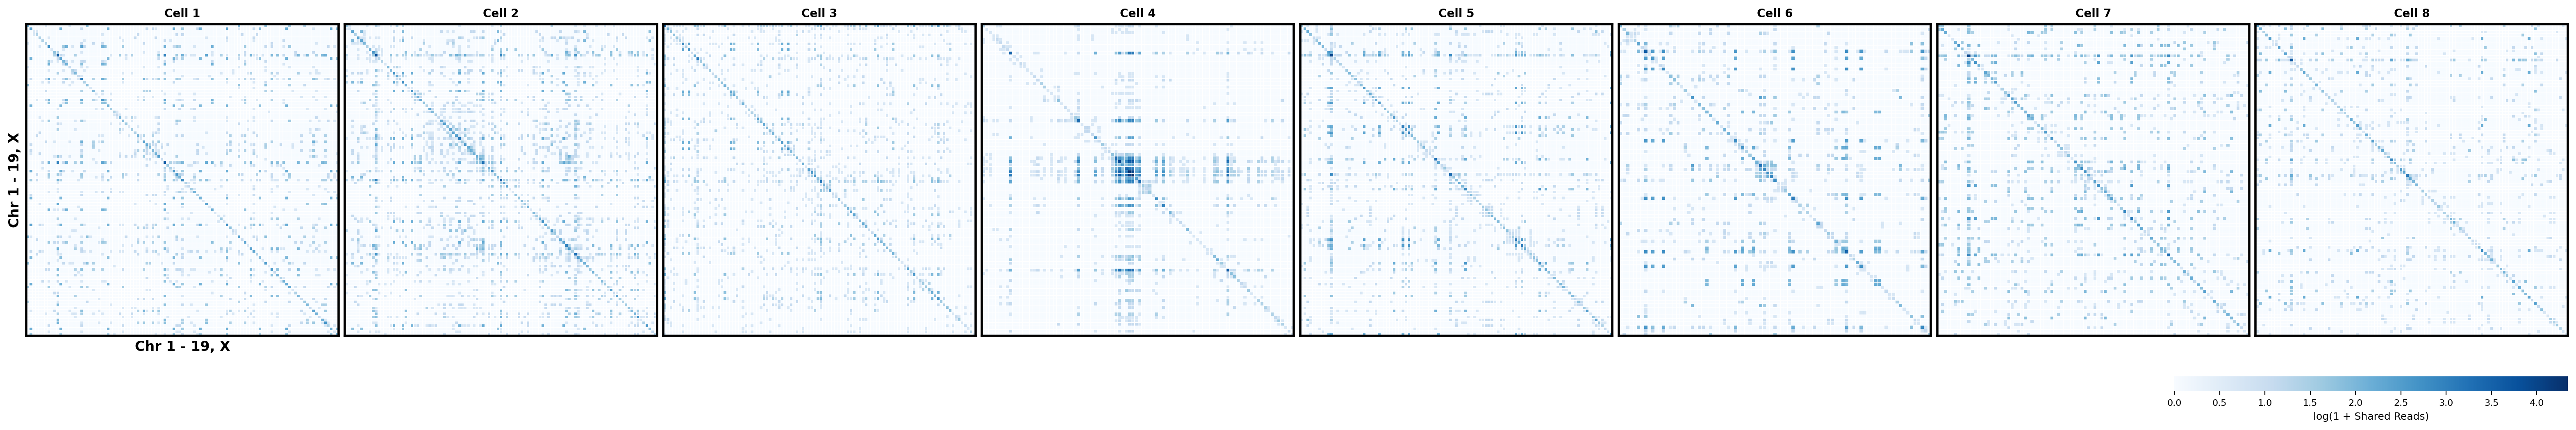

In [124]:
axes = plot_contact_matrices_panel(
    incidence_dfs=incidence_list,
    spath='contact_panel_cells_w_core_nvm.png',
    log_transform=True,
    cmap = 'Blues',
)

### Incidence Matrix w/ Histogram 

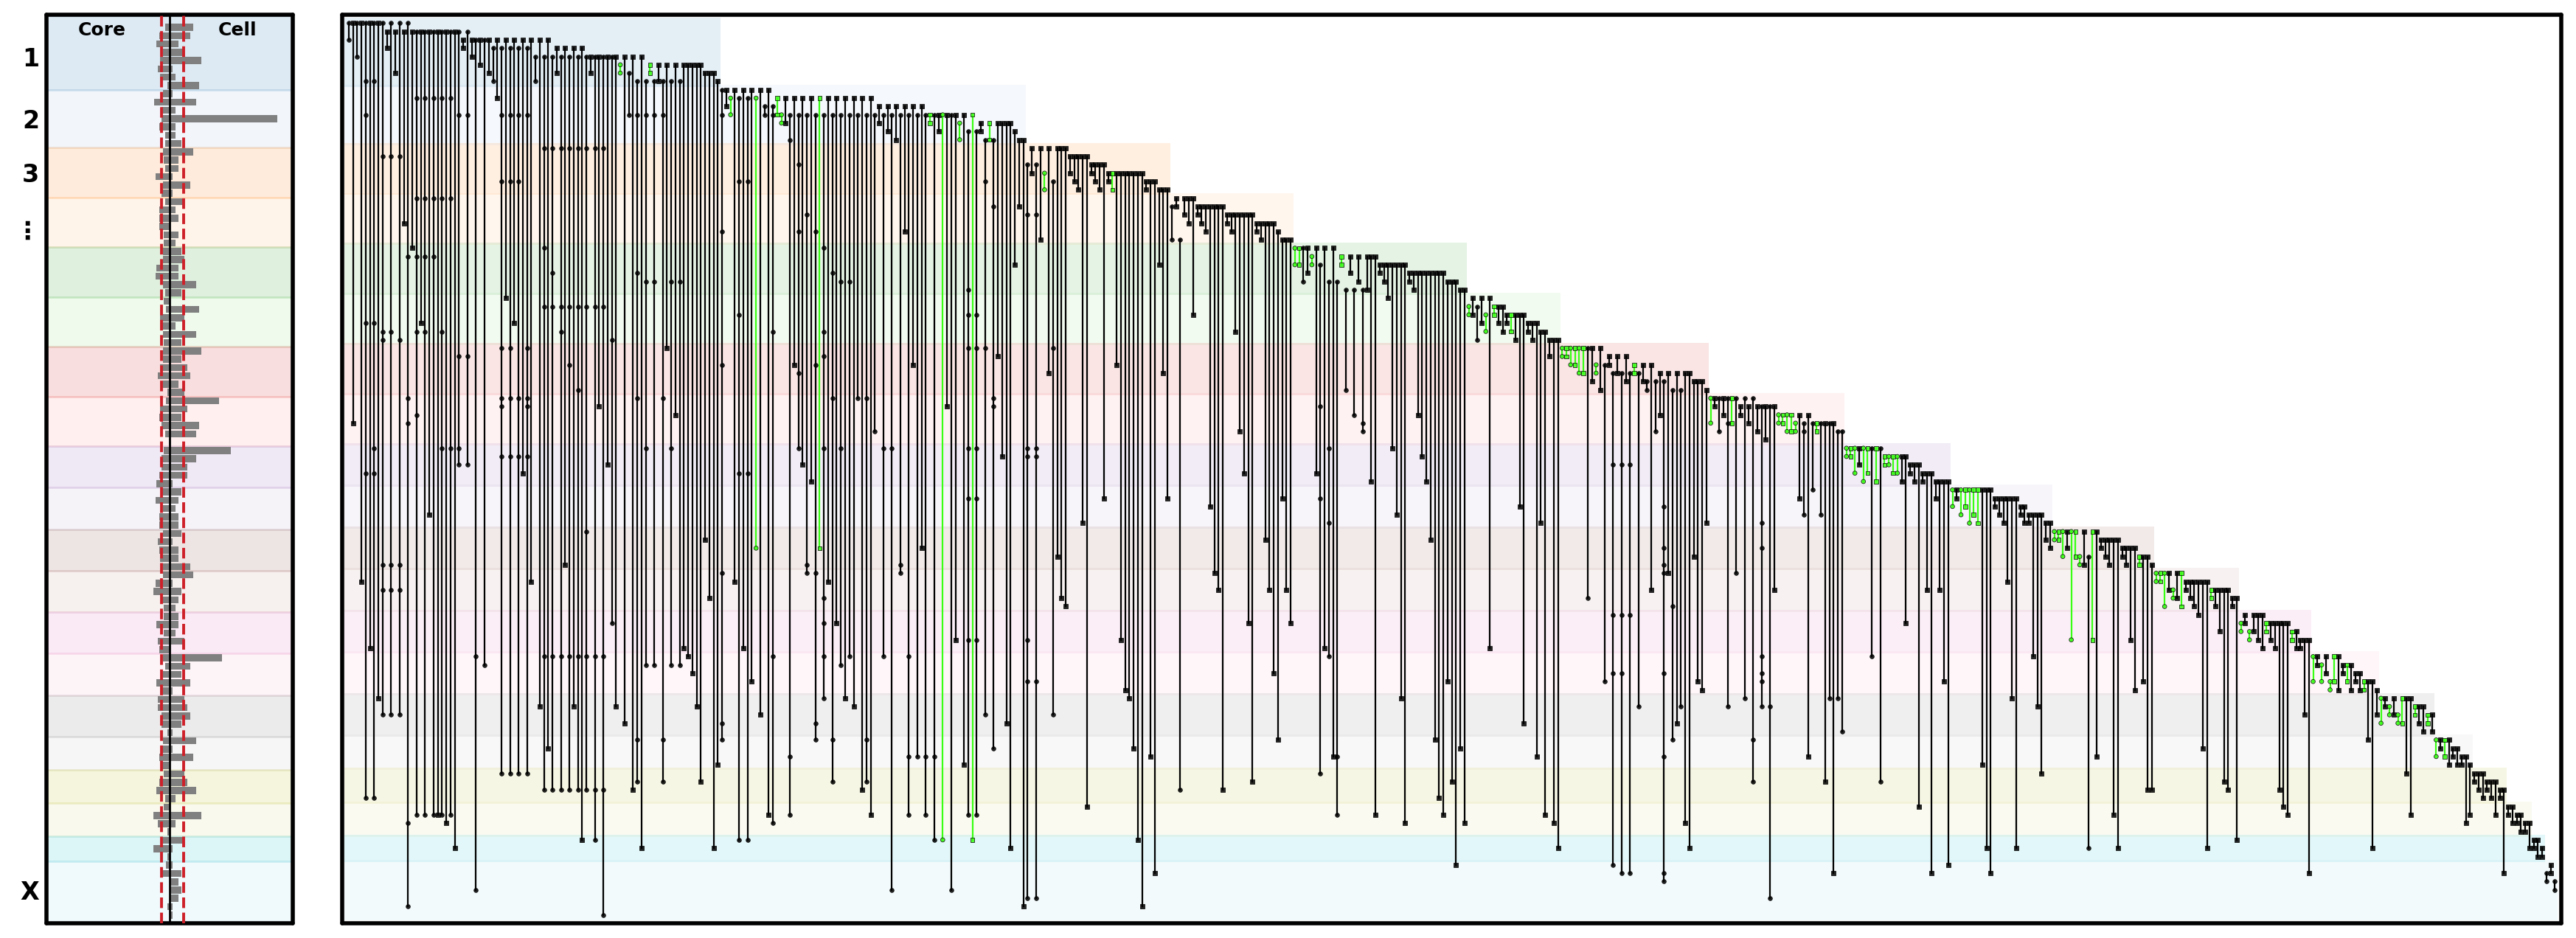

In [35]:
ax, hist_a, matrix = plot.genomic_combined_dual_plot_v2(
    incidence_df_a=im_cell,
    incidence_df_b=im_core,
    spath="dual_plot_core_cell_o3b07.png",
    shared_dict=shared,
)

### Contact Matrix Plot

In [38]:
def plot_contact_matrix_equation(
    incidence_sc,
    incidence_core,
    spath,
    log_transform=True,
    cmap='Blues',
    dpi=200,
    figsize=(21, 7),
):
    plt.rcParams['figure.dpi'] = dpi
    plt.rcParams["axes.edgecolor"] = "black"
    plt.rcParams["axes.linewidth"] = 2.50

    # ------------------------------------------------------------------ #
    #  1. Align both matrices to a shared union bin space                  #
    # ------------------------------------------------------------------ #
    union_bins = incidence_sc.index.union(incidence_core.index)

    sc_aligned   = incidence_sc.reindex(union_bins,   fill_value=0).astype(float)
    core_aligned = incidence_core.reindex(union_bins, fill_value=0).astype(float)

    H_sc   = sc_aligned.values
    H_core = core_aligned.values

    # ------------------------------------------------------------------ #
    #  2. Build contact matrices                                           #
    # ------------------------------------------------------------------ #
    cm_sc   = H_sc   @ H_sc.T
    cm_core = H_core @ H_core.T
    cm_comb = cm_sc  + cm_core

    # ------------------------------------------------------------------ #
    #  3. Optional log transform                                           #
    # ------------------------------------------------------------------ #
    if log_transform:
        d_sc   = np.log1p(cm_sc)
        d_core = np.log1p(cm_core)
        d_comb = np.log1p(cm_comb)
        cbar_label = 'log(1 + Shared Reads)'
    else:
        d_sc   = cm_sc
        d_core = cm_core
        d_comb = cm_comb
        cbar_label = 'Shared Reads'

    vmin = 0
    vmax = max(d_sc.max(), d_core.max(), d_comb.max())

    # ------------------------------------------------------------------ #
    #  4. Red overlay mask                                                 #
    # ------------------------------------------------------------------ #
    new_contacts_mask = (cm_core > 0) & (cm_sc == 0)

    # ------------------------------------------------------------------ #
    #  5. Layout — three equal heatmap axes, then a slim cbar axes        #
    #     added manually in figure coordinates after drawing              #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(nrows=1, ncols=3,
                             figsize=figsize,
                             gridspec_kw={'wspace': 0.50})
    ax_sc, ax_core, ax_comb = axes

    n_bins = len(union_bins)

    # ------------------------------------------------------------------ #
    #  6. Helper: draw a heatmap panel                                     #
    # ------------------------------------------------------------------ #
    def _heatmap(ax, data, title):
        sns.heatmap(
            data,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            square=False,
            cbar=False,
            linewidths=0.3,
            linecolor='white',
            xticklabels=False,
            yticklabels=False,
        )
        ax.tick_params(left=False, bottom=False)
        ax.set_xlabel('Chr 1-19, X', fontweight='bold')
        ax.set_ylabel('Chr 1-19, X', fontweight='bold')
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)


    # ------------------------------------------------------------------ #
    #  7. Draw the three panels                                            #
    # ------------------------------------------------------------------ #
    _heatmap(ax_sc,   d_sc,   'Single-Cell')
    _heatmap(ax_core, d_core, 'Core Contact')
    _heatmap(ax_comb, d_comb, 'Combined Contact')
    
    # ------------------------------------------------------------------ #
    #  7b. Force all three axes to identical sizes AFTER seaborn draws   #
    #      seaborn's square=True can cause them to drift                  #
    # ------------------------------------------------------------------ #
    fig.canvas.draw()  # force renderer so get_position() is accurate
    
    # Use the first axes as the reference size
    pos_ref = ax_sc.get_position()
    
    # Compute a square size from the reference
    side = min(pos_ref.width, pos_ref.height)
    
    # Reposition all three axes to the same square dimensions,
    # keeping their horizontal centres aligned with original positions
    for ax in [ax_sc, ax_core, ax_comb]:
        pos = ax.get_position()
        cx  = pos.x0 + pos.width  / 2   # horizontal centre
        cy  = pos.y0 + pos.height / 2   # vertical centre
        ax.set_position([
            cx - side / 2,   # x0
            cy - side / 2,   # y0
            side,            # width
            side,            # height
        ])
    
    # Verify all three are identical (will print warnings if not)
    positions = [ax.get_position() for ax in [ax_sc, ax_core, ax_comb]]
    for i, pos in enumerate(positions):
        if abs(pos.width - positions[0].width) > 1e-6 or \
           abs(pos.height - positions[0].height) > 1e-6:
            print(f"WARNING: axes {i} size mismatch — "
                  f"w={pos.width:.6f}, h={pos.height:.6f} "
                  f"vs ref w={positions[0].width:.6f}, h={positions[0].height:.6f}")
        else:
            print(f"axes {i} size OK: w={pos.width:.6f}, h={pos.height:.6f}")
    # ------------------------------------------------------------------ #
    #  8. Red overlay on combined panel                                    #
    # ------------------------------------------------------------------ #
    red_overlay = np.zeros((n_bins, n_bins, 4), dtype=float)
    red_overlay[new_contacts_mask] = [1.0, 0.0, 0.0, 0.55]

    ax_comb.imshow(
        red_overlay,
        aspect='auto',
        origin='upper',
        extent=[-0.5, n_bins - 0.5, n_bins - 0.5, -0.5],
        zorder=5,
        interpolation='nearest',
    )

    red_patch = mpatches.Patch(
        facecolor=(1, 0, 0, 0.55),
        edgecolor='black',
        linewidth=0.8,
        label='New contacts from core',
    )



    # ------------------------------------------------------------------ #
    #  9. Colorbar — anchored to the combined panel, won't affect layout  #
    # ------------------------------------------------------------------ #
    plt.subplots_adjust(wspace=0.05, bottom=0.30)
    
    # Anchor a thin colorbar just below ax_comb
    # width="60%"  → 60% of the axes width
    # height="3%"  → controls thickness (make smaller to thin it out)
    # loc           → where inside ax_comb to anchor it
    # borderpad     → how many font-units away from the axes edge
    cax = inset_axes(
        ax_comb,
        width="100%",        # fraction of ax_comb width — adjust as needed
        height="4%",        # thickness of the colorbar — decrease to make thinner
        loc='lower center', # anchor point on ax_comb
        borderpad=-3,       # negative value pulls it closer/outside the axes
    )
    
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=vmin, vmax=vmax),
    )
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label(cbar_label, fontsize=7, labelpad=4)
    cbar.ax.tick_params(labelsize=6)
    
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    

    # ------------------------------------------------------------------ #
    #  10. Save                                                            #
    # ------------------------------------------------------------------ #
    plt.savefig(spath, dpi=dpi, bbox_inches='tight')
    plt.show()

    return {
        'sc':         cm_sc,
        'core':       cm_core,
        'combined':   cm_comb,
        'union_bins': union_bins,
    }

axes 0 size OK: w=0.193750, h=0.193750
axes 1 size OK: w=0.193750, h=0.193750
axes 2 size OK: w=0.193750, h=0.193750


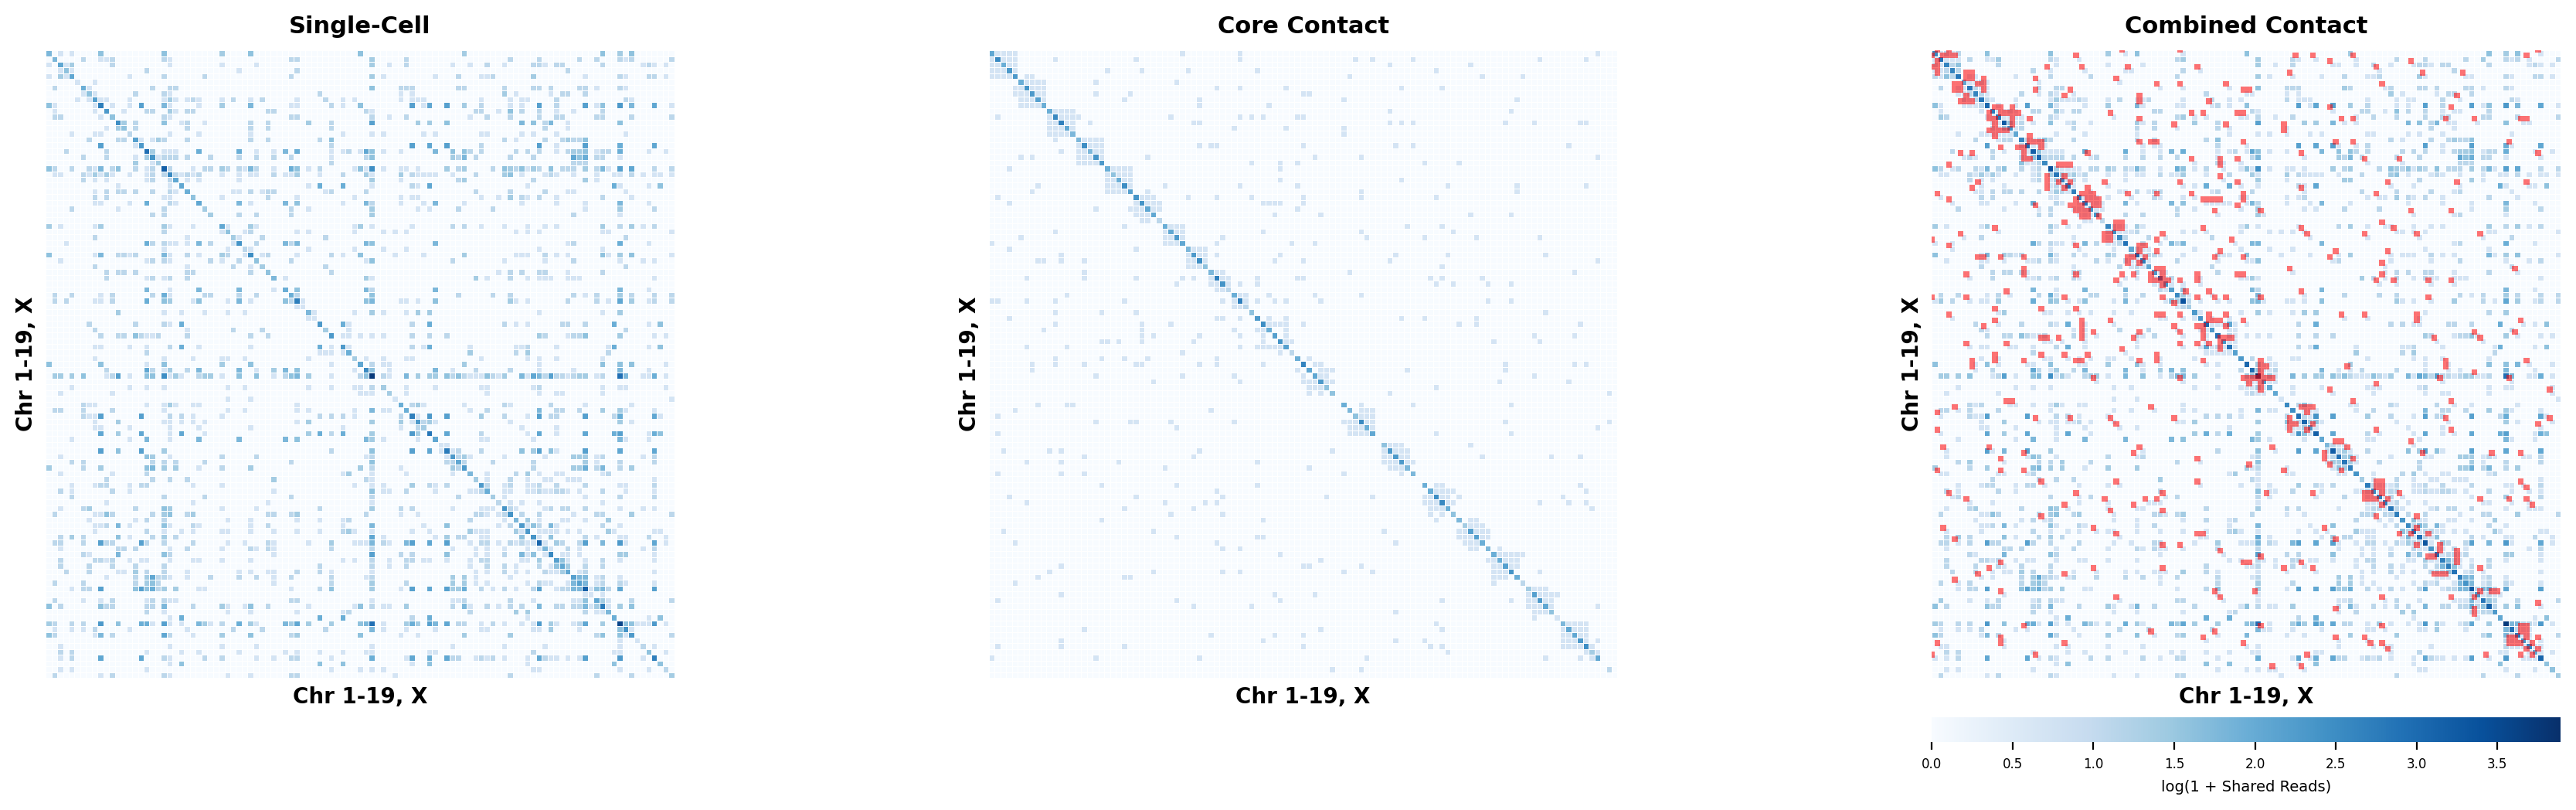

In [39]:
contact_matrices = plot_contact_matrix_equation(
    incidence_sc=im_cell,        # your single-cell DataFrame
    incidence_core=im_core,    # your core DataFrame
    spath='contact_equation_1mb.png',
    log_transform=True,
    cmap='Blues',
    dpi=200,
    figsize=(21, 7),
)